In [3]:
!pip install transformers datasets torch --upgrade

In [4]:
import pandas as pd
import os

# Check current folder
print("Current Directory:", os.getcwd())
print("Files Here:", os.listdir())

train_path = "archive (1).zip"

Current Directory: c:\Users\HP\OneDrive\Desktop\Movie Genre Classification\movie-genre-classification\notebooks
Files Here: ['01_eda.ipynb', '02_baseline_model.ipynb', '03_bert_experiments.ipynb', 'results']


In [5]:
import os
print("Current Folder:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Folder: c:\Users\HP\OneDrive\Desktop\Movie Genre Classification\movie-genre-classification\notebooks
Files in this folder: ['01_eda.ipynb', '02_baseline_model.ipynb', '03_bert_experiments.ipynb', 'results']


In [6]:
train_path = "../data/raw/Genre Classification Dataset/train_data.txt"

import pandas as pd

df = pd.read_csv(train_path, sep=" ::: ", engine="python", header=None)
df.columns = ["id", "title", "genre", "plot"]

df.head()

,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [7]:
df.shape

(54214, 4)

In [8]:
df['genre'].value_counts().head()

genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
Name: count, dtype: int64

In [9]:
df['genre'].nunique()

27

In [10]:
sorted(df['genre'].unique())

['action',
 'adult',
 'adventure',
 'animation',
 'biography',
 'comedy',
 'crime',
 'documentary',
 'drama',
 'family',
 'fantasy',
 'game-show',
 'history',
 'horror',
 'music',
 'musical',
 'mystery',
 'news',
 'reality-tv',
 'romance',
 'sci-fi',
 'short',
 'sport',
 'talk-show',
 'thriller',
 'war',
 'western']

In [11]:
df.isnull().sum()

id       0
title    0
genre    0
plot     0
dtype: int64

In [12]:
df['plot_length'] = df['plot'].apply(lambda x: len(str(x).split()))

df['plot_length'].describe()

count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: plot_length, dtype: float64

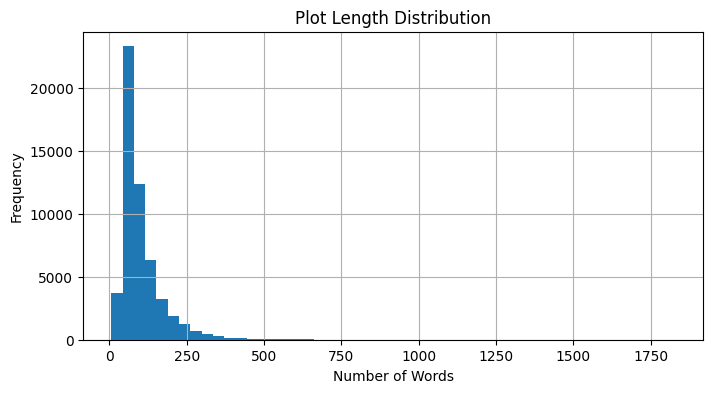

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df['plot_length'].hist(bins=50)
plt.title("Plot Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [14]:
df['genre'].nunique()

27

In [15]:
df.isnull().sum()

id             0
title          0
genre          0
plot           0
plot_length    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['genre'].value_counts(normalize=True).head()

genre
drama          0.251098
documentary    0.241561
comedy         0.137363
short          0.093574
horror         0.040654
Name: proportion, dtype: float64

In [18]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove special characters & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 4. Remove stopwords + Lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [20]:
df['clean_plot'] = df['plot'].apply(clean_text)

In [21]:
df[['plot', 'clean_plot']].head()

,plot,clean_plot
0,Listening in to a conversation between his doc...,listening conversation doctor parent yearold o...
1,A brother and sister with a past incestuous re...,brother sister past incestuous relationship cu...
2,As the bus empties the students for their fiel...,bus empty student field trip museum natural hi...
3,To help their unemployed father make ends meet...,help unemployed father make end meet edith twi...
4,The film's title refers not only to the un-rec...,film title refers unrecovered body ground zero...


In [22]:
df['clean_length'] = df['clean_plot'].apply(lambda x: len(x.split()))

df[['plot_length', 'clean_length']].describe()

,plot_length,clean_length
count,54214.000000,54214.000000
mean,101.907386,56.864537
std,76.579192,42.360223
min,6.000000,4.000000
25%,55.000000,31.000000
50%,79.000000,44.000000
75%,121.000000,68.000000
max,1829.000000,1416.000000


In [23]:
df.to_csv("../data/processed/train_clean.csv", index=False)

In [24]:
df[['plot', 'clean_plot']].head()

,plot,clean_plot
0,Listening in to a conversation between his doc...,listening conversation doctor parent yearold o...
1,A brother and sister with a past incestuous re...,brother sister past incestuous relationship cu...
2,As the bus empties the students for their fiel...,bus empty student field trip museum natural hi...
3,To help their unemployed father make ends meet...,help unemployed father make end meet edith twi...
4,The film's title refers not only to the un-rec...,film title refers unrecovered body ground zero...


In [25]:
from sklearn.model_selection import train_test_split

X = df['clean_plot']
y = df['genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (43371,)
Test size: (10843,)


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (43371, 10000)
Test TF-IDF shape: (10843, 10000)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_tfidf, y_train)

y_pred_log = log_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression Macro F1:", f1_score(y_test, y_pred_log, average='macro'))

Logistic Regression Accuracy: 0.4687817024808632
Logistic Regression Macro F1: 0.35458433749632856


In [28]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Macro F1:", f1_score(y_test, y_pred_nb, average='macro'))

Naive Bayes Accuracy: 0.5153555289126626
Naive Bayes Macro F1: 0.1250648643933813


In [29]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Macro F1:", f1_score(y_test, y_pred_svm, average='macro'))

SVM Accuracy: 0.5721663746195702
SVM Macro F1: 0.34297455921868775


In [30]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Balanced SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Balanced SVM Macro F1:", f1_score(y_test, y_pred_svm, average='macro'))

Balanced SVM Accuracy: 0.5090842017891727
Balanced SVM Macro F1: 0.3440062927083634


In [31]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=3
)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(43371, 20000)


In [33]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

log_model.fit(X_train_tfidf, y_train)

y_pred_log = log_model.predict(X_test_tfidf)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Macro F1:", f1_score(y_test, y_pred_log, average='macro'))

Logistic Accuracy: 0.48113990593009315
Logistic Macro F1: 0.36195626259269165


In [34]:
log_model = LogisticRegression(
    C=2,
    max_iter=2000,
    class_weight='balanced'
)

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

      action       0.33      0.49      0.39       263
       adult       0.38      0.71      0.49       118
   adventure       0.19      0.32      0.24       155
   animation       0.18      0.28      0.22       100
   biography       0.03      0.06      0.04        53
      comedy       0.60      0.46      0.52      1490
       crime       0.15      0.35      0.21       101
 documentary       0.78      0.59      0.67      2619
       drama       0.69      0.39      0.50      2723
      family       0.17      0.34      0.23       157
     fantasy       0.11      0.22      0.15        65
   game-show       0.67      0.72      0.69        39
     history       0.09      0.27      0.13        49
      horror       0.58      0.65      0.61       441
       music       0.39      0.77      0.51       146
     musical       0.13      0.24      0.17        55
     mystery       0.12      0.17      0.14        64
        news       0.17    

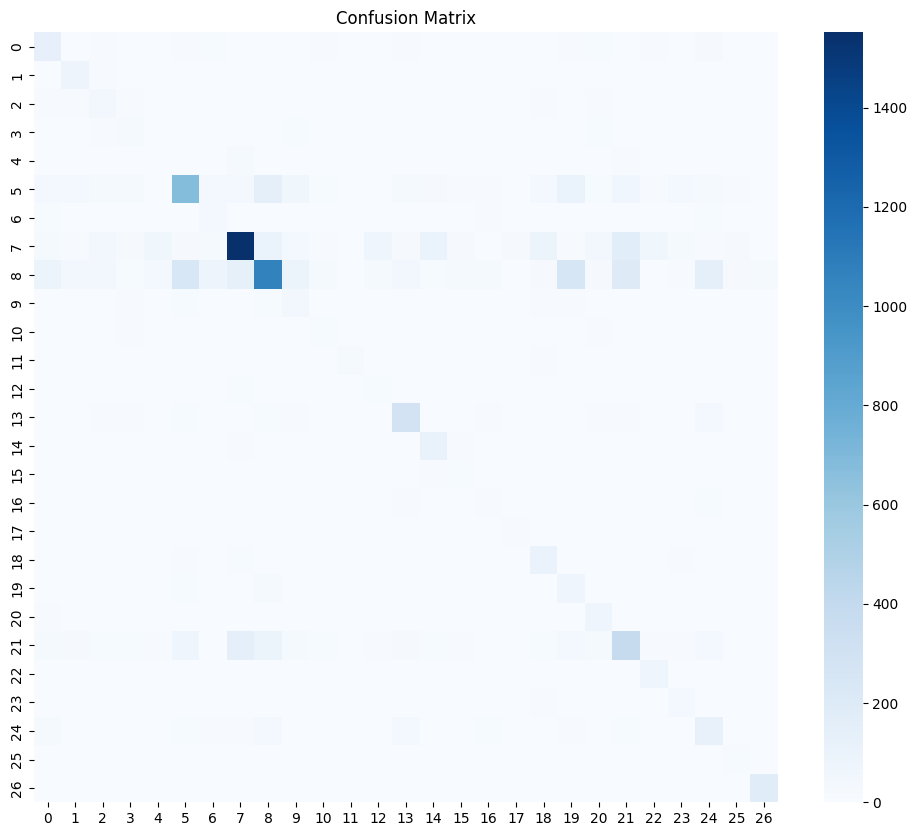

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [37]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    C=2,
    max_iter=3000,
    class_weight='balanced'
)

log_model.fit(X_train_tfidf, y_train)

y_pred = log_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.5217190814350272
Macro F1: 0.3804657751321288


In [38]:
import joblib

joblib.dump(log_model, "../models/baseline_logistic.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [39]:
X = df['plot']
y = df['genre']

In [40]:
from sklearn.preprocessing import LabelEncoder

X = df['plot']
y = df['genre']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_labels = len(label_encoder.classes_)
print("Number of classes:", num_labels)

Number of classes: 27


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [42]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})

test_dataset = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})

In [43]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [44]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/43371 [00:00<?, ? examples/s]

Map:   0%|          | 0/10843 [00:00<?, ? examples/s]

In [45]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
!pip install --upgrade transformers

In [47]:
import transformers
print(transformers.__version__)

5.2.0


In [48]:
do_eval=True,
logging_steps=500,

In [49]:
import sys
!{sys.executable} -m pip install --upgrade transformers

In [50]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    do_eval=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [51]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro")
    }

In [52]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [53]:
train_dataset
test_dataset

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 10843
})

In [54]:
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.NO,
eval_use_gather_object=False,


In [55]:
compute_metrics

<function __main__.compute_metrics(eval_pred)>

In [56]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)